In [163]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as ss
import sklearn
import os
import sktree

In [164]:
# load data
wise = pd.read_csv('./wise.matrix')
wise_all = pd.read_csv('./wise_All.matrix')
display(wise.head())
print(wise.shape)
wise_y = wise['Cancer Status']
wise_X = wise.drop(columns = ['Cancer Status', 'Sample', 'Tumor type', 'Stage'])
print(wise_X.shape)

,Sample,Cancer Status,Stage,Tumor type,1:1-10000000,1:10000001-20000000,1:20000001-30000000,1:30000001-40000000,1:40000001-50000000,1:50000001-60000000,...,21:10000001-20000000,21:20000001-30000000,21:30000001-40000000,21:40000001-50000000,22:1-10000000,22:10000001-20000000,22:20000001-30000000,22:30000001-40000000,22:40000001-50000000,22:50000001-60000000
0,S0035.INDI_998_PLS_1,1,IV,Ovary,0.107617,-0.089664,0.088308,0.161890,0.195141,0.059390,...,-1.072653,-0.931427,-0.835283,-0.817325,0.0,-1.819371,-1.749369,-1.684808,-1.647312,-1.532646
1,S0035.INDI_983_PLS_1,1,IV,Ovary,-0.772378,-1.087627,-0.949005,0.489450,-0.670958,-0.221170,...,-0.897900,-0.524623,-0.922448,-0.793396,0.0,-0.675361,-0.943580,-0.758821,-0.932769,-0.749762
2,S0035.INDI_510_PLS_1A,1,IV,Ovary,-1.519912,-1.795528,-1.847208,0.015104,0.541656,0.411293,...,-0.796892,0.147432,-0.221206,-0.270937,0.0,-3.158424,-1.795942,-1.927368,-1.657170,-1.819905
3,S0063.INDIA_3343_PLS_1,1,IIIA,Lung,3.058270,2.851708,2.665363,-0.828755,-0.752899,-0.695762,...,-1.603144,-1.409415,-0.781825,-0.207052,0.0,2.169607,1.920353,-0.745165,-0.920590,-0.716167
4,S0064.INDIA_3360_PLS_1,1,IIB,Lung,0.017034,0.189540,-0.901394,-0.537247,-0.986964,-0.564267,...,0.044192,0.188299,0.263522,1.150110,0.0,-0.045028,-0.220047,0.243085,1.025034,1.885327


(704, 304)
(704, 300)


In [165]:
display(wise_all.head())
print(wise_all.shape)
wise_all_y = wise_all['Cancer Status']
wise_all_X = wise_all.drop(columns = ['Run','Library','Cancer Status', 'Sample', 'Tumor type', 'Stage'])
print(wise_all_X.shape)

,Run,Sample,Library,Cancer Status,Stage,Tumor type,1:1-10000000,1:10000001-20000000,1:20000001-30000000,1:30000001-40000000,...,21:10000001-20000000,21:20000001-30000000,21:30000001-40000000,21:40000001-50000000,22:1-10000000,22:10000001-20000000,22:20000001-30000000,22:30000001-40000000,22:40000001-50000000,22:50000001-60000000
0,S0028,INDI_918_PLS_1A,A387-12,Cancer,IV,Stomach,0.468038,-3.145530,-1.712623,-0.735046,...,-1.135428,0.910290,-0.814004,0.465840,NaN,-2.455095,0.242265,-0.999295,0.586578,4.020335
1,S0028,INDI_980_PLS_1,A387-13,Cancer,IV,Stomach,0.632628,-3.349720,-0.246645,-0.336667,...,-0.728640,0.982447,-1.233654,1.355670,NaN,2.373436,4.932168,-0.335874,0.462123,2.862172
2,S0034,INDI_580_PLS_1A,A396-13,Cancer,IV,Colorectal,-2.123124,-2.840198,-2.896575,-2.638872,...,0.540503,-0.127143,-0.174641,0.031823,NaN,0.298749,-0.050700,-0.240639,0.109563,0.532129
3,S0034,INDI_730_PLS_1A,A396-04,Cancer,IV,Pancreas,-1.318004,-1.953182,-1.099582,-0.309286,...,0.567452,-0.766169,-0.743883,1.192330,NaN,-2.766405,0.101859,-1.526696,0.981383,-1.887319
4,S0034,INDI_481_PLS_1A,A396-10,Cancer,IV,Liver,0.199915,-1.960120,-1.531292,-0.322800,...,-2.222321,0.856329,-0.179628,-0.078619,NaN,-7.305575,-3.274674,-1.136304,-0.444130,0.926091


(1991, 306)
(1991, 300)


In [166]:
# train a Random Forest model on the WISE data
from sklearn.ensemble import RandomForestClassifier
from joblib import Parallel, delayed
from scipy.stats import false_discovery_control
from statsmodels.stats.multitest import multipletests

def statistics(feature_importance, idx, n_estimators=100):
    r"""
    Helper function that calulates the feature importance
    test statistic.
    """
    stat = np.zeros(len(feature_importance[0]))
    for ii in range(n_estimators):
        r = ss.rankdata(1-feature_importance[idx[ii]], method="max")
        r_0 = ss.rankdata(1-feature_importance[idx[n_estimators + ii]], method="max")
        stat += (r_0 > r) * 1
    stat /= n_estimators
    return stat


def perm_stat(feature_importance, n_estimators=1000):
    r"""
    Helper function that calulates the null distribution.
    """
    idx = list(range(2 * n_estimators))
    # print(idx)
    np.random.shuffle(idx)
    # print(idx)
    return statistics(feature_importance, idx)


def test(feature_importance, n_repeats=1000, n_jobs=-1, n_estimators=1000):
    r"""
    Calculates p values for fearture imprtance test.
    Parameters
    ----------
    X : ArrayLike of shape (n_samples, n_features)
        The data matrix.
    y : ArrayLike of shape (n_samples, n_outputs)
        The target matrix.
    n_repeats : int, optional
        Number of times to sample the null distribution, by default 1000.
    n_jobs : int, optional
        Number of workers to use, by default 1000.
    Returns
    -------
    stat : float
        The computed discriminability statistic.
    pvalue : float
        The computed one sample test p-value.
    """
    stat = statistics(feature_importance, list(range(2 * n_estimators)), n_estimators=n_estimators)
    # print(stat)
    null_stat = Parallel(n_jobs=n_jobs)(
        delayed(perm_stat)(feature_importance, n_estimators=n_estimators)
        for _ in range(n_repeats)
    )
    count = np.sum((null_stat >= stat) * 1, axis=0)
    p_val = (1 + count) / (1 + n_repeats)
    # adjust p-value for multiple testing using Bonferroni-Holm correction
    # rank the p-values
    ranks = ss.rankdata(1-p_val)
    p_val_adusted = p_val * ranks / len(p_val)
    return stat, p_val,p_val_adusted

In [167]:

X = wise_X
y = wise_y
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# train using 
model = RandomForestClassifier(n_estimators=1000, n_jobs=10)
model.fit(X_train,y_train)
# test the model on the test data
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

# feature_importance_origin = model.feature_importances_
# feature_importance per tree is a array of size n_features, so you get a list of n_estimators arrays
feature_importance_origin = [tree.feature_importances_ for tree in model.estimators_]
# print(len(feature_importance_origin[0]))
permuted_model = RandomForestClassifier(n_estimators=1000, n_jobs=10)
y_cp = y_train.copy()
# shuffle the labels
y_cp = np.random.permutation(y_cp)
# np.random.shuffle(y_cp)
permuted_model.fit(X_train,y_cp)
permuted_feature_importance = [tree.feature_importances_ for tree in permuted_model.estimators_]
# del permuted_model
feature_importance = np.concatenate((feature_importance_origin,permuted_feature_importance))
# print(len(feature_importance))
stat, p_val, p_val_adusted = test(feature_importance,
            n_repeats = 1000,
            n_jobs = 10,
            n_estimators = 1000)
# print(stat, p_val, p_val_adusted)


0.9787234042553191


In [172]:
# sort the columns by p-value
p_val_df = pd.DataFrame(p_val, columns = ['p_value'])
p_val_df['feature'] = X_train.columns
p_val_sorted = p_val_df.sort_values(by = 'p_value')
k = len(p_val_sorted)
rev_idx = np.linspace(1, k, k)[::-1]
# multiply the p-values by the number of tests
p_val_sorted['p_value_adjusted'] = p_val_sorted['p_value'] * rev_idx/k
# sort it by the index
p_val_IB = p_val_sorted.sort_index()
display(p_val_IB.head())

,p_value,feature,p_value_adjusted
0,0.996004,1:1-10000000,0.232401
1,0.948052,1:10000001-20000000,0.644675
2,0.994006,1:20000001-30000000,0.284948
3,0.945055,1:30000001-40000000,0.655238
4,0.990010,1:40000001-50000000,0.339903


In [53]:
# show the top 10 p-values
sorted_idx = np.argsort(p_val)
print(sorted_idx[:10])
print(p_val[sorted_idx[:10]])
# do the same with adjusted p-values
sorted_idx = np.argsort(p_val_adusted)
print(sorted_idx[:10])
print(p_val_adusted[sorted_idx[:10]])
# more or less the same

[156 157 287 154  80  17 152 155 150  67]
[0.000999   0.000999   0.001998   0.01198801 0.02197802 0.02397602
 0.03096903 0.03396603 0.04195804 0.05094905]
[157 156 287 154  80  17 152 155 150  67]
[0.00099734 0.00099734 0.00198468 0.01186813 0.02168498 0.02357642
 0.03034965 0.03317349 0.04083916 0.04942058]


# Apply the held-out set and get the feature importance

In [64]:
(model.estimators_[0].tree_.feature ==-2).sum()
# show the number of leaves in the first tree
(model.estimators_[0].tree_.n_leaves)

26

In [67]:
from sklearn.tree import _tree

def tree_to_code(tree, feature_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    # print("def tree({}):".format(", ".join(feature_names)))

    def recurse(node, depth):
        indent = "   " * depth
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]
            print( "{}if {} <= {}:".format(indent, name, threshold))
            recurse(tree_.children_left[node], depth + 1)
            print( "{}else:  # if {} > {}".format(indent, name, threshold))
            recurse(tree_.children_right[node], depth + 1)
        else:
            print( "{}return {}".format(indent, tree_.value[node]))

    recurse(0, 1)

# test the function
tree_to_code(model.estimators_[0], X.columns)

   if 4:150000001-160000000 <= -0.7676481604576111:
      if 4:60000001-70000000 <= 0.5064537525177002:
         if 5:40000001-50000000 <= -1.1041279435157776:
            if 1:60000001-70000000 <= -1.6688593626022339:
               return [[0. 1.]]
            else:  # if 1:60000001-70000000 > -1.6688593626022339
               return [[1. 0.]]
         else:  # if 5:40000001-50000000 > -1.1041279435157776
            if 4:140000001-150000000 <= -0.5038848221302032:
               if 3:100000001-110000000 <= -1.069160908460617:
                  if 2:10000001-20000000 <= 0.6789622008800507:
                     return [[0. 1.]]
                  else:  # if 2:10000001-20000000 > 0.6789622008800507
                     return [[1. 0.]]
               else:  # if 3:100000001-110000000 > -1.069160908460617
                  return [[0. 1.]]
            else:  # if 4:140000001-150000000 > -0.5038848221302032
               if 7:90000001-100000000 <= 0.6240536421537399:
                  

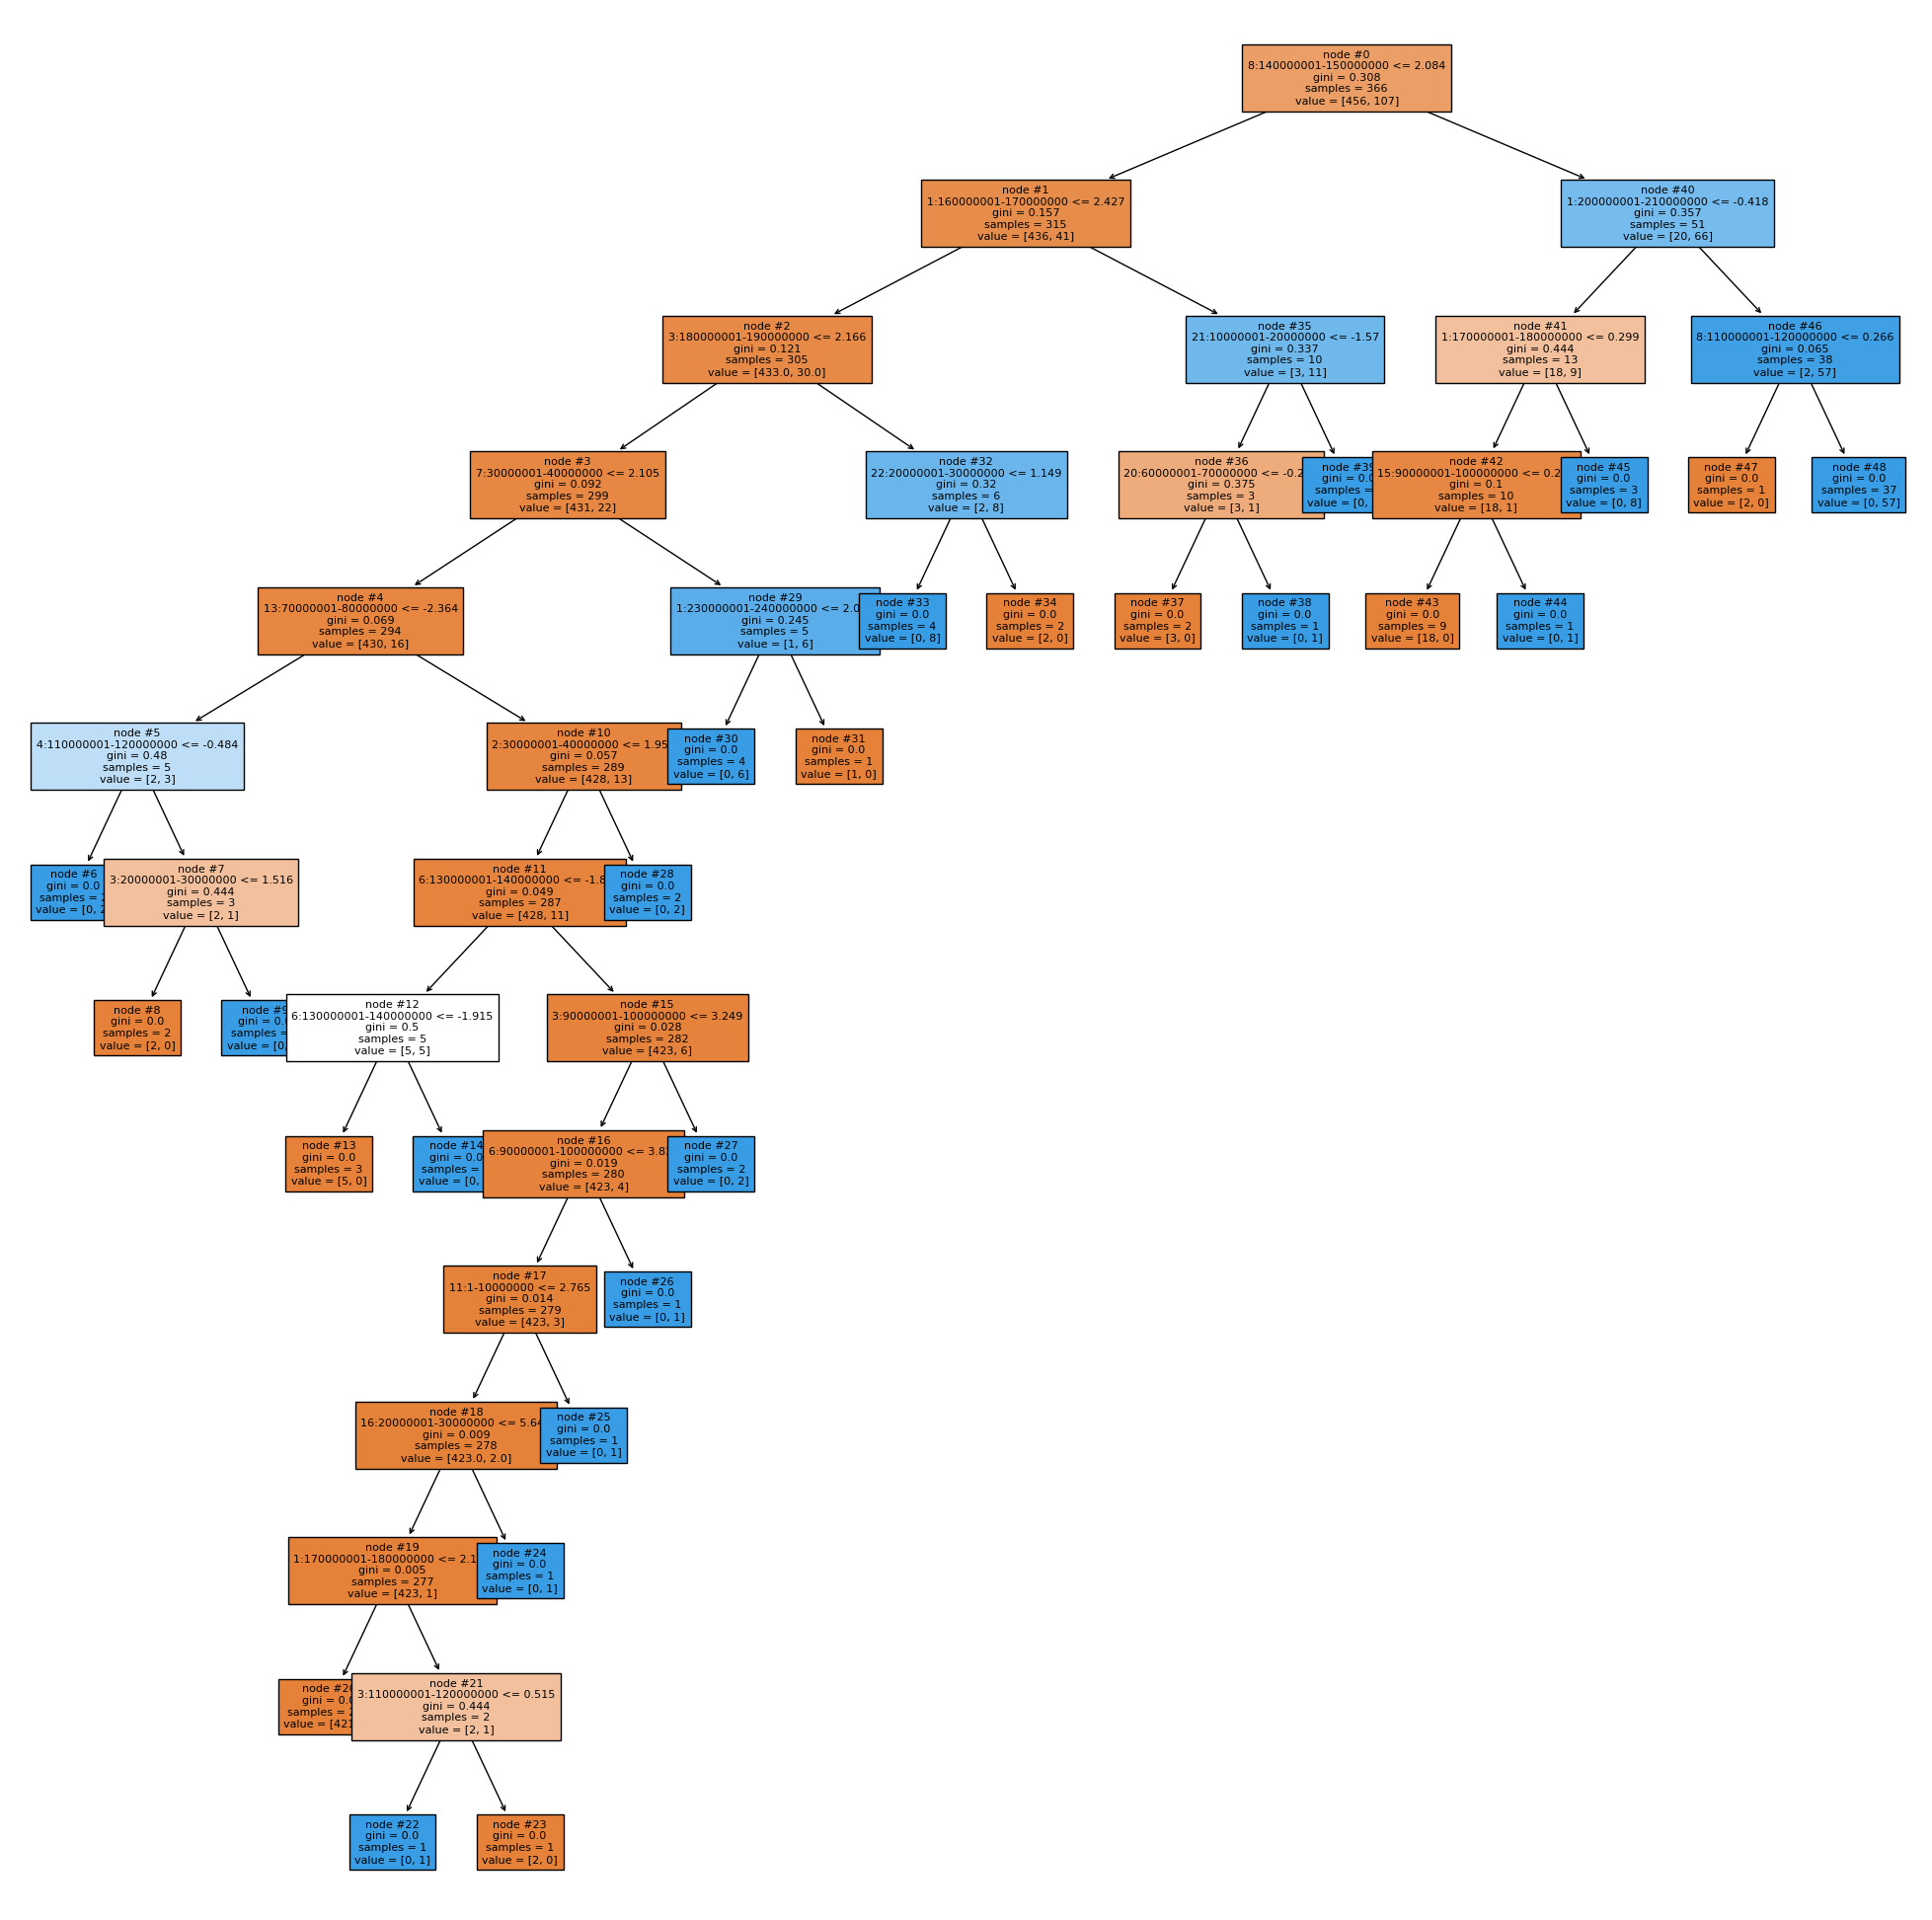

In [71]:
# print out the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(25,25))
plot_tree(model.estimators_[2], feature_names = X.columns, filled = True, node_ids=True, fontsize=8, impurity=True)
plt.show()

In [7]:
tree_i = model.estimators_[0].tree_
tree_i.apply(X_train.to_numpy().astype(np.float32))

array([ 8,  8, 35,  8, 24,  8, 32,  8, 19,  8,  8,  8, 19,  8,  8,  8,  8,
       24,  8,  8,  8,  8,  8,  8, 24,  8,  8,  8,  8, 21, 23,  8, 32,  8,
        8, 32,  8, 24, 32,  8,  8,  8,  8, 32,  8,  8,  8,  8,  8, 32,  8,
        8,  8,  8, 13,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8, 32,  8,  8,
        8,  8, 17, 19,  8, 32,  8, 24,  8,  8,  8, 32,  8,  8, 17,  8,  8,
        8,  8,  8, 24, 16,  8,  8,  8, 26, 32, 16,  8,  8,  8,  8,  8,  8,
       32,  8,  8,  8, 20,  8,  8,  8,  8,  8,  8,  8,  8,  8, 32,  8,  8,
        8, 20,  8, 23, 32, 32,  8,  8, 20,  8,  8, 32, 16,  8,  8, 13,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8, 24, 32,  8,
        8,  8,  8,  8,  8,  8,  8,  8, 32,  8, 36,  8, 21,  8,  8,  8,  8,
       32,  8, 32,  8, 20,  8,  8, 27,  8, 32,  8,  8,  8, 36,  8,  8,  8,
        8,  8, 27, 17,  8,  8,  8,  8,  8,  8,  8,  8,  8, 19,  8,  8,  8,
        8, 27, 32, 11,  8,  8,  8, 24,  8,  8,  8,  8,  8,  8, 32,  8,  8,
       24,  8,  8,  8, 32

In [24]:
# predict the test data
y_pred = model.predict(X_test)
# inspect the gini importance on the test data
model.estimators_[0].tree_.n_node_samples

array([344, 298, 289, 275, 273, 262, 258, 255, 253,   2,   1,   1,   3,
         1,   2,   4,   2,   2,  11,   5,   6,   2,  14,   4,  10,   9,
         1,   8,  46,  39,   1,  38,  37,   1,   7,   2,   5], dtype=int64)

In [140]:
from sklearn.tree import DecisionTreeClassifier

# train using X_train, y_train
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

node_indicator = model.decision_path(X_test)
leave_id = model.apply(X_test)
sample_id = 0
node_index = node_indicator.indices[node_indicator.indptr[sample_id]: node_indicator.indptr[sample_id + 1]]
for node in node_index:
    print(node, model.tree_.feature[node], model.tree_.threshold[node])
print(leave_id[sample_id])

0 156 1.8675665259361267
20 155 0.8568698465824127
21 128 0.4409226179122925
22 286 2.559413433074951
23 -2 -2.0
23


In [141]:
# collect all the samples at each node
from collections import defaultdict
# copy the model
from copy import deepcopy
model_cp = deepcopy(model)

tree_nodes = defaultdict(list)
node_indicator = model.decision_path(X_test)
leave_id = model.apply(X_test)
for sample_id in range(X_test.shape[0]):
    node_index = node_indicator.indices[node_indicator.indptr[sample_id]: node_indicator.indptr[sample_id + 1]]
    for node in node_index:
        tree_nodes[node].append(sample_id)
# calcurate the gini impurity for each node
for node in range(model.tree_.node_count):
    sample_ids = tree_nodes[node]
    if len(sample_ids) == 0:
        continue
    model_cp.tree_.impurity[node] = 1 - np.sum(np.square(np.bincount(np.array(y_test)[sample_ids]) / len(sample_ids)))

print(model_cp.tree_.impurity, len(model_cp.tree_.impurity))
print(model.tree_.impurity, len(model.tree_.impurity))

[0.42935466 0.20244898 0.26035503 0.         0.         0.20244898
 0.16233703 0.09777872 0.48       0.         0.         0.
 0.         0.04253308 0.04298998 0.         0.         0.375
 0.         0.         0.19753086 0.         0.         0.
 0.         0.         0.05876951 0.         0.         0.
 0.        ] 31
[0.30565765 0.13005422 0.26035503 0.         0.         0.09126594
 0.06041637 0.03971877 0.4260355  0.         0.18       0.
 0.         0.00477324 0.         0.         0.         0.32
 0.         0.         0.31735298 0.33240997 0.1171875  0.
 0.         0.         0.07986111 0.         0.02816327 0.
 0.        ] 31


# Feature Importance using OOB samples

In [145]:
# do above for all the trees
# 1. train a random forest model using X_train, y_train
model = RandomForestClassifier(n_estimators=1000, n_jobs=10)
model.fit(X_train, y_train)
# 2. copy the model
model_cp = deepcopy(model)
# 3. for each tree in the model do the following
for i, tree in enumerate(model.estimators_):
    # 3.1. copy the tree
    tree_cp = deepcopy(tree)
    # 3.2. collect all the samples at each node
    tree_nodes = defaultdict(list)
    node_indicator = tree.decision_path(X_test)
    leave_id = tree.apply(X_test)
    for sample_id in range(X_test.shape[0]):
        node_index = node_indicator.indices[node_indicator.indptr[sample_id]: node_indicator.indptr[sample_id + 1]]
        # check if the nodes in the node_indicator are the same as the nodes in the tree
        assert np.array_equal(len(tree.tree_.impurity), tree.tree_.node_count)
        for node in node_index:
            tree_nodes[node].append(sample_id)
    # 3.3. calcurate the gini impurity for each node
    for node in range(tree.tree_.node_count):
        sample_ids = tree_nodes[node]
        if len(sample_ids) == 0:
            continue
        tree_cp.tree_.impurity[node] = 1 - np.sum(np.square(np.bincount(np.array(y_test)[sample_ids]) / len(sample_ids)))
    # compute the feature importance
    tree_cp.tree_.compute_feature_importances(normalize=False)
    # 3.4. replace the tree in the copied model with the new tree
    model_cp.estimators_[i] = tree_cp
# 4. normalize the feature importance of the copied model
test_sample_feature_importance = model_cp.feature_importances_ / model_cp.feature_importances_.sum()

# print(test_sample_feature_importance)

/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/en

[ 2.15375744e-04  6.03413597e-04  1.13390477e-03  1.27013624e-03
  4.66339053e-04  1.07881010e-03  1.25003747e-03  1.06948094e-03
  4.14619978e-04  5.19958277e-04  3.00555437e-04  2.41958865e-04
  0.00000000e+00  0.00000000e+00  3.83620678e-04  1.66112081e-02
  6.24397897e-03  2.50000575e-02  9.77279458e-03  3.81827855e-03
  2.49247877e-03  3.08466630e-02  5.33077650e-04  4.60756393e-03
  1.67831185e-02  4.08739562e-04  7.19852117e-04  4.38487178e-04
  6.72402847e-04  6.53752527e-04  5.20640462e-04  4.40682021e-04
  2.75129021e-04  3.01799087e-04  0.00000000e+00  1.18643931e-04
  1.01980357e-04  2.82274883e-04  1.89352206e-04  1.16006519e-04
  3.10900997e-04  7.94920036e-05  3.16165543e-04  4.62263433e-04
  1.54249152e-04  2.07090581e-04  1.03317076e-04  1.40952033e-04
  1.02104377e-04  1.78833405e-04  4.75532707e-04  9.11736484e-05
  3.38707008e-04  2.69137156e-04  1.80916681e-04  5.25588284e-04
  1.52079430e-04  1.72502301e-04  1.67906941e-04  3.10391165e-04
  4.61316265e-04  3.93690

/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/envs/might/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/suki/miniconda3/en

In [146]:
# calcurate p-value for the feature importance
test_samples_feature_importance = [tree.feature_importances_ for tree in model_cp.estimators_]
# do the same for the permuted model
permuted_model = RandomForestClassifier(n_estimators=1000, n_jobs=10)
y_test_perm = y_test.copy()
# shuffle the labels
y_test_perm = np.random.permutation(y_test_perm)
# np.random.shuffle(y_cp)
permuted_model.fit(X_test,y_test_perm)
permuted_feature_importance = [tree.feature_importances_ for tree in permuted_model.estimators_]

feature_importance_test = np.concatenate((feature_importance_origin,permuted_feature_importance))
# print(len(feature_importance))
stat_test, p_val_test, p_val_adusted_test = test(feature_importance_test,
            n_repeats = 1000,
            n_jobs = 10,
            n_estimators = 1000)

In [154]:
# sort the columns by p-value
p_val__test_df = pd.DataFrame(p_val_test, columns = ['p_value'])
p_val__test_df['feature'] = X_train.columns
p_val_test_sorted = p_val__test_df.sort_values(by = 'p_value')
k = len(p_val_test_sorted)
rev_idx = np.linspace(1, k, k)[::-1]
# multiply the p-values by the number of tests
p_val_test_sorted['p_value_adjusted'] = p_val_test_sorted['p_value'] * rev_idx/k
# sort the p-values by the adjusted p-values
p_val_test_sorted.sort_values(by = 'p_value_adjusted')[:].drop(columns = ['p_value']).to_csv('wise_feature_importance_test.csv', index = False)
# show the top 10 p-values

p_val_test_sorted[['feature', 'p_value_adjusted']][:30]

,feature,p_value_adjusted
157,8:140000001-150000000,0.000999
156,8:130000001-140000000,0.000996
154,8:110000001-120000000,0.000992
150,8:70000001-80000000,0.000989
80,4:100000001-110000000,0.001971
288,20:60000001-70000000,0.001965
149,8:60000001-70000000,0.002937
155,8:120000001-130000000,0.002927
152,8:90000001-100000000,0.002917
67,3:170000001-180000000,0.002907


In [160]:
p_val__test_df['mean_feature_importance'] =  model_cp.feature_importances_
p_val__test_df.sort_values(by = 'mean_feature_importance', ascending = False).drop(columns = ['p_value']).to_csv('wise_mean_feature_importance_test.csv', index = False)

In [186]:
p_val_OOB['mean_feature_importance_OOB'] =  model_cp.feature_importances_

In [200]:
p_val_OOB



,feature,mean_feature_importance_OOB,p_value_OOB,p_value_adjusted_OOB
0,1:1-10000000,0.000215,0.799201,0.133200
1,1:10000001-20000000,0.000603,0.476523,0.276384
2,1:20000001-30000000,0.001134,0.371628,0.253946
3,1:30000001-40000000,0.001270,0.518482,0.264426
4,1:40000001-50000000,0.000466,0.655345,0.203157
...,...,...,...,...
295,22:10000001-20000000,0.000260,0.221778,0.179640
296,22:20000001-30000000,0.000441,0.742258,0.148452
297,22:30000001-40000000,0.001653,0.428571,0.270000
298,22:40000001-50000000,0.000972,0.405594,0.267692


In [216]:

p_val_IB

,feature,mean_feature_importance_IB,p_value_IB,p_value_adjusted_IB
0,1:1-10000000,0.000608,0.996004,0.232401
1,1:10000001-20000000,0.002132,0.948052,0.644675
2,1:20000001-30000000,0.002697,0.994006,0.284948
3,1:30000001-40000000,0.001362,0.945055,0.655238
4,1:40000001-50000000,0.000661,0.990010,0.339903
...,...,...,...,...
295,22:10000001-20000000,0.001055,0.990010,0.343203
296,22:20000001-30000000,0.000886,1.000000,0.090000
297,22:30000001-40000000,0.001732,0.840160,0.694532
298,22:40000001-50000000,0.001689,0.910090,0.691668


In [217]:
# join the two dataframes
p_val_IB = p_val_IB.set_index('feature')
p_val_OOB = p_val_OOB.set_index('feature')
p_val_IB_OOB = p_val_IB.join(p_val_OOB, how = 'inner')
p_val_IB_OOB

,mean_feature_importance_IB,p_value_IB,p_value_adjusted_IB,mean_feature_importance_OOB,p_value_OOB,p_value_adjusted_OOB
feature,,,,,,
1:1-10000000,0.000608,0.996004,0.232401,0.000215,0.799201,0.133200
1:10000001-20000000,0.002132,0.948052,0.644675,0.000603,0.476523,0.276384
1:20000001-30000000,0.002697,0.994006,0.284948,0.001134,0.371628,0.253946
1:30000001-40000000,0.001362,0.945055,0.655238,0.001270,0.518482,0.264426
1:40000001-50000000,0.000661,0.990010,0.339903,0.000466,0.655345,0.203157
...,...,...,...,...,...,...
22:10000001-20000000,0.001055,0.990010,0.343203,0.000260,0.221778,0.179640
22:20000001-30000000,0.000886,1.000000,0.090000,0.000441,0.742258,0.148452
22:30000001-40000000,0.001732,0.840160,0.694532,0.001653,0.428571,0.270000


In [219]:
# read the dataframes
p_val_IB_OOB = pd.read_csv('wise_feature_importance_IB_OOB.csv')
p_val_IB_OOB

,feature,mean_feature_importance_IB,p_value_IB,p_value_adjusted_IB,mean_feature_importance_OOB,p_value_OOB,p_value_adjusted_OOB
0,1:1-10000000,0.000608,0.996004,0.232401,0.000215,0.799201,0.133200
1,1:10000001-20000000,0.002132,0.948052,0.644675,0.000603,0.476523,0.276384
2,1:20000001-30000000,0.002697,0.994006,0.284948,0.001134,0.371628,0.253946
3,1:30000001-40000000,0.001362,0.945055,0.655238,0.001270,0.518482,0.264426
4,1:40000001-50000000,0.000661,0.990010,0.339903,0.000466,0.655345,0.203157
...,...,...,...,...,...,...,...
295,22:10000001-20000000,0.001055,0.990010,0.343203,0.000260,0.221778,0.179640
296,22:20000001-30000000,0.000886,1.000000,0.090000,0.000441,0.742258,0.148452
297,22:30000001-40000000,0.001732,0.840160,0.694532,0.001653,0.428571,0.270000
298,22:40000001-50000000,0.001689,0.910090,0.691668,0.000972,0.405594,0.267692


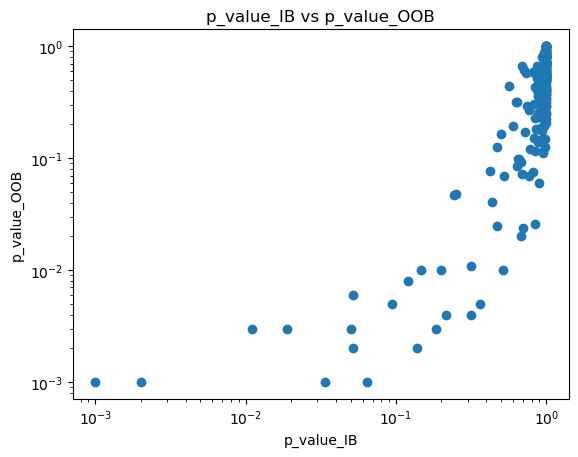

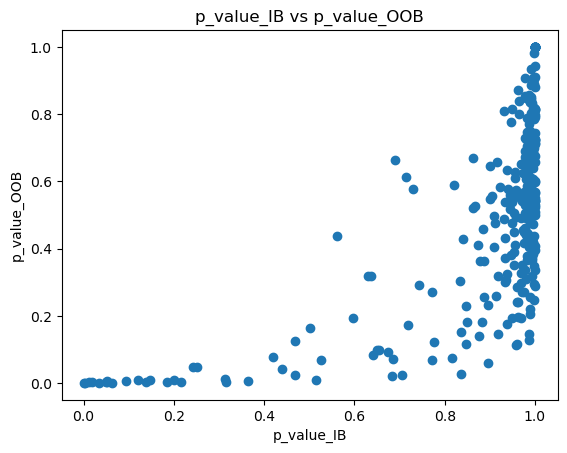

In [238]:
# plot the 'p_value_IB' vs 'p_value_OOB'
plt.scatter(p_val_IB_OOB['p_value_IB'], p_val_IB_OOB['p_value_OOB'])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('p_value_IB')
plt.ylabel('p_value_OOB')
plt.title('p_value_IB vs p_value_OOB')
plt.show()
plt.scatter(p_val_IB_OOB['p_value_IB'], p_val_IB_OOB['p_value_OOB'])
# plt.xscale('log')
# plt.yscale('log')
plt.xlabel('p_value_IB')
plt.ylabel('p_value_OOB')
plt.title('p_value_IB vs p_value_OOB')
plt.show()

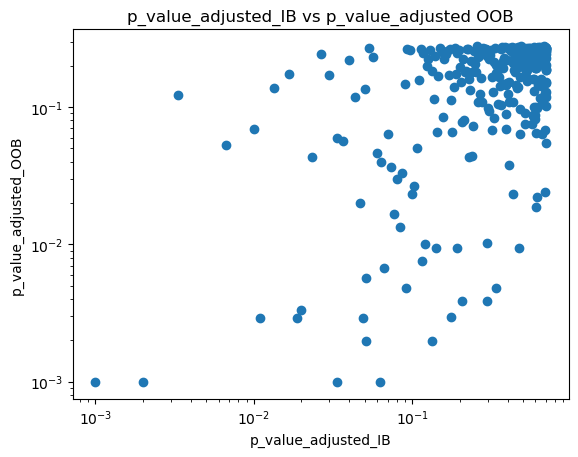

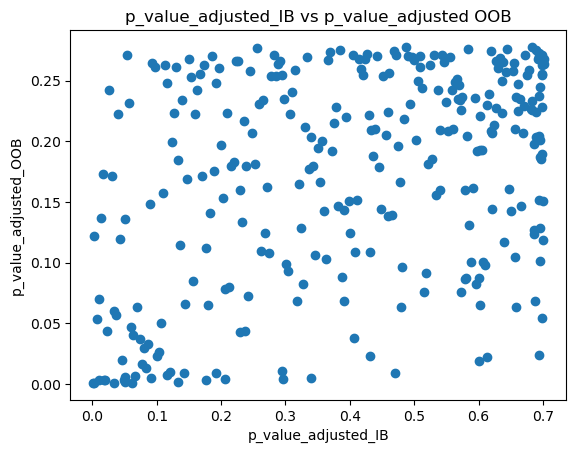

In [240]:
# plot the 'p_value_adjusted_IB' vs 'p_value_adjusted_OOB'
plt.scatter(p_val_IB_OOB['p_value_adjusted_IB'], p_val_IB_OOB['p_value_adjusted_OOB'])
# plt.xlim(0, 1)
# plt.ylim(0, 1)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('p_value_adjusted_IB')
plt.ylabel('p_value_adjusted_OOB')
plt.title('p_value_adjusted_IB vs p_value_adjusted OOB')
plt.show()

plt.scatter(p_val_IB_OOB['p_value_adjusted_IB'], p_val_IB_OOB['p_value_adjusted_OOB'])
plt.xlabel('p_value_adjusted_IB')
plt.ylabel('p_value_adjusted_OOB')
plt.title('p_value_adjusted_IB vs p_value_adjusted OOB')
plt.show()

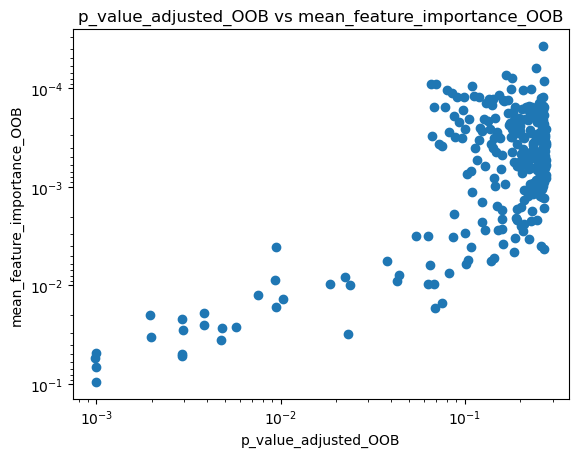

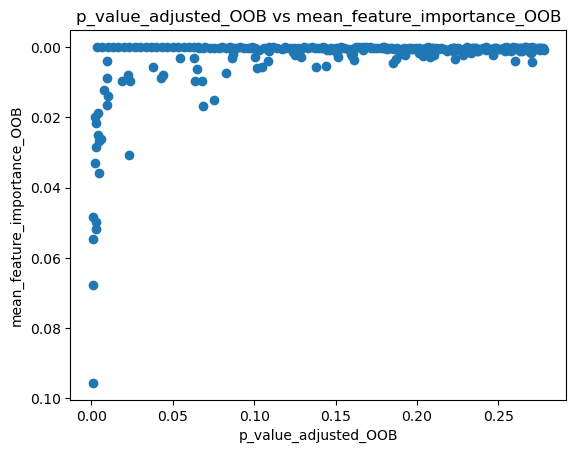

In [244]:
# plot the 'p_value_adjusted_OOB' vs 'mean_feature_importance_OOB'
plt.scatter(p_val_IB_OOB['p_value_adjusted_OOB'], p_val_IB_OOB['mean_feature_importance_OOB'])
# reverse the y-axis
plt.gca().invert_yaxis()
plt.xscale('log')
plt.yscale('log')
plt.xlabel('p_value_adjusted_OOB')
plt.ylabel('mean_feature_importance_OOB')
plt.title('p_value_adjusted_OOB vs mean_feature_importance_OOB')
plt.show()

plt.scatter(p_val_IB_OOB['p_value_adjusted_OOB'], p_val_IB_OOB['mean_feature_importance_OOB'])
plt.gca().invert_yaxis()
plt.xlabel('p_value_adjusted_OOB')
plt.ylabel('mean_feature_importance_OOB')
plt.title('p_value_adjusted_OOB vs mean_feature_importance_OOB')
plt.show()

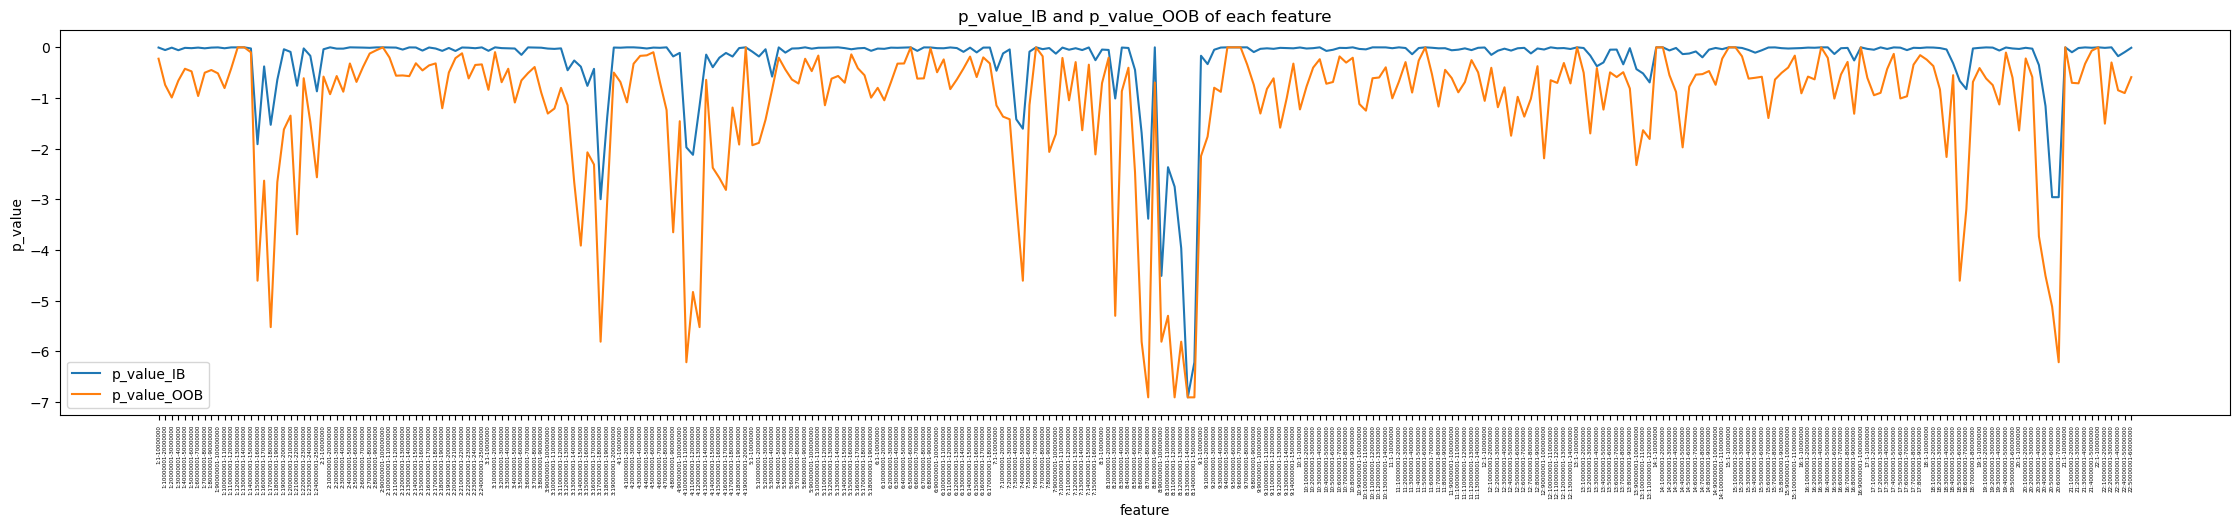

In [262]:
# plot p_val_IB and p_val_OOB of each feature
plt.figure(figsize=(28,5))
plt.plot(p_val_IB_OOB['feature'], np.log(p_val_IB_OOB['p_value_IB']), label = 'p_value_IB')
plt.plot(p_val_IB_OOB['feature'], np.log(p_val_IB_OOB['p_value_OOB']), label = 'p_value_OOB')
plt.xlabel('feature')
# make the xlabel smaller
plt.xticks(fontsize = 4)
plt.ylabel('p_value')
plt.title('p_value_IB and p_value_OOB of each feature')
# rotate the x-axis labels by 90 degrees
plt.xticks(rotation=90)
plt.legend()
plt.show()

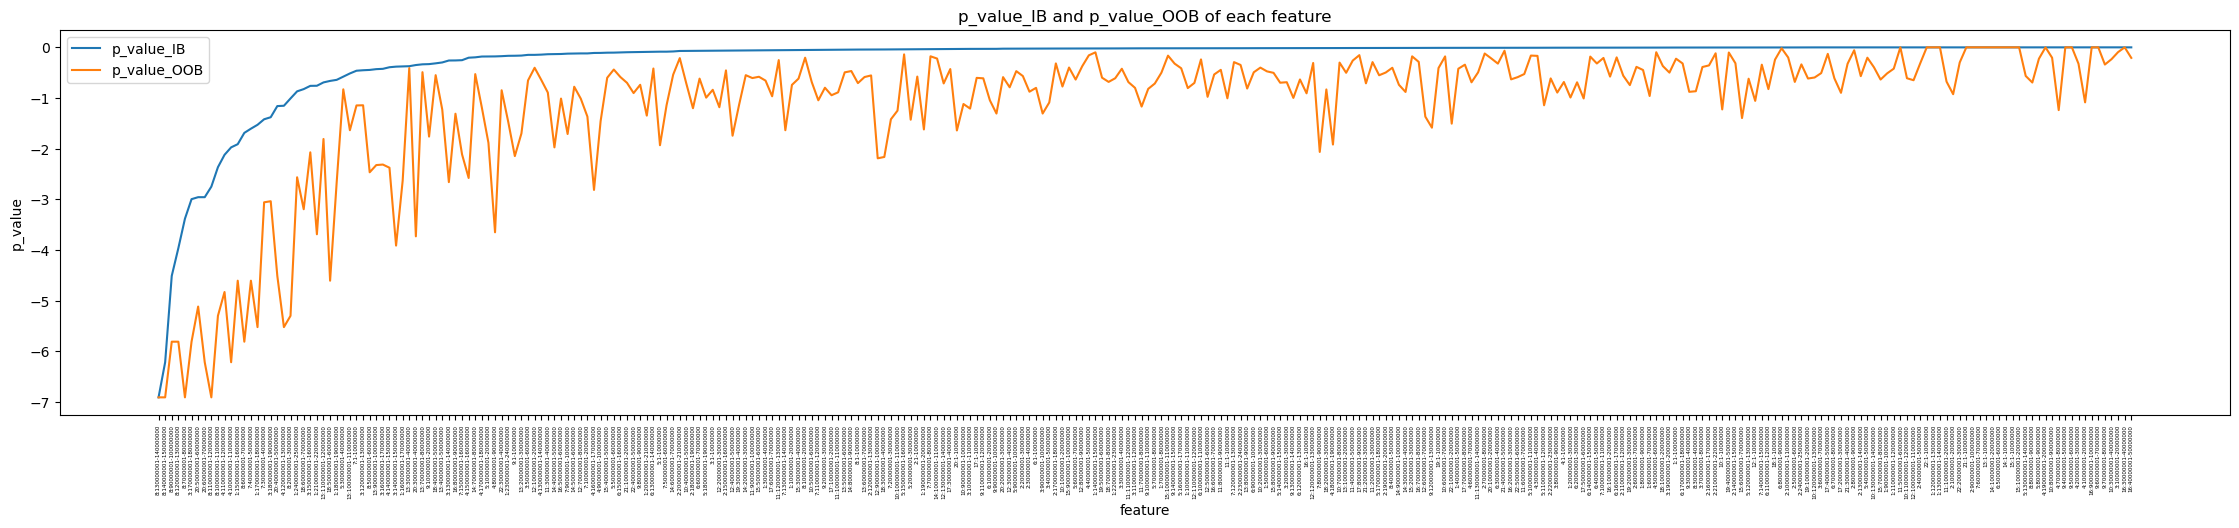

In [266]:
# sort the df by the p_value_IB
p_val_IB_OOB_sorted = p_val_IB_OOB.sort_values(by = 'p_value_IB')
plt.figure(figsize=(28,5))
plt.plot(p_val_IB_OOB_sorted['feature'], np.log(p_val_IB_OOB_sorted['p_value_IB']), label = 'p_value_IB')
plt.plot(p_val_IB_OOB_sorted['feature'], np.log(p_val_IB_OOB_sorted['p_value_OOB']), label = 'p_value_OOB')
plt.xlabel('feature')
# make the xlabel smaller
plt.xticks(fontsize = 4)
plt.ylabel('p_value')
plt.title('p_value_IB and p_value_OOB of each feature')
# rotate the x-axis labels by 90 degrees
plt.xticks(rotation=90)
plt.legend()
plt.show()

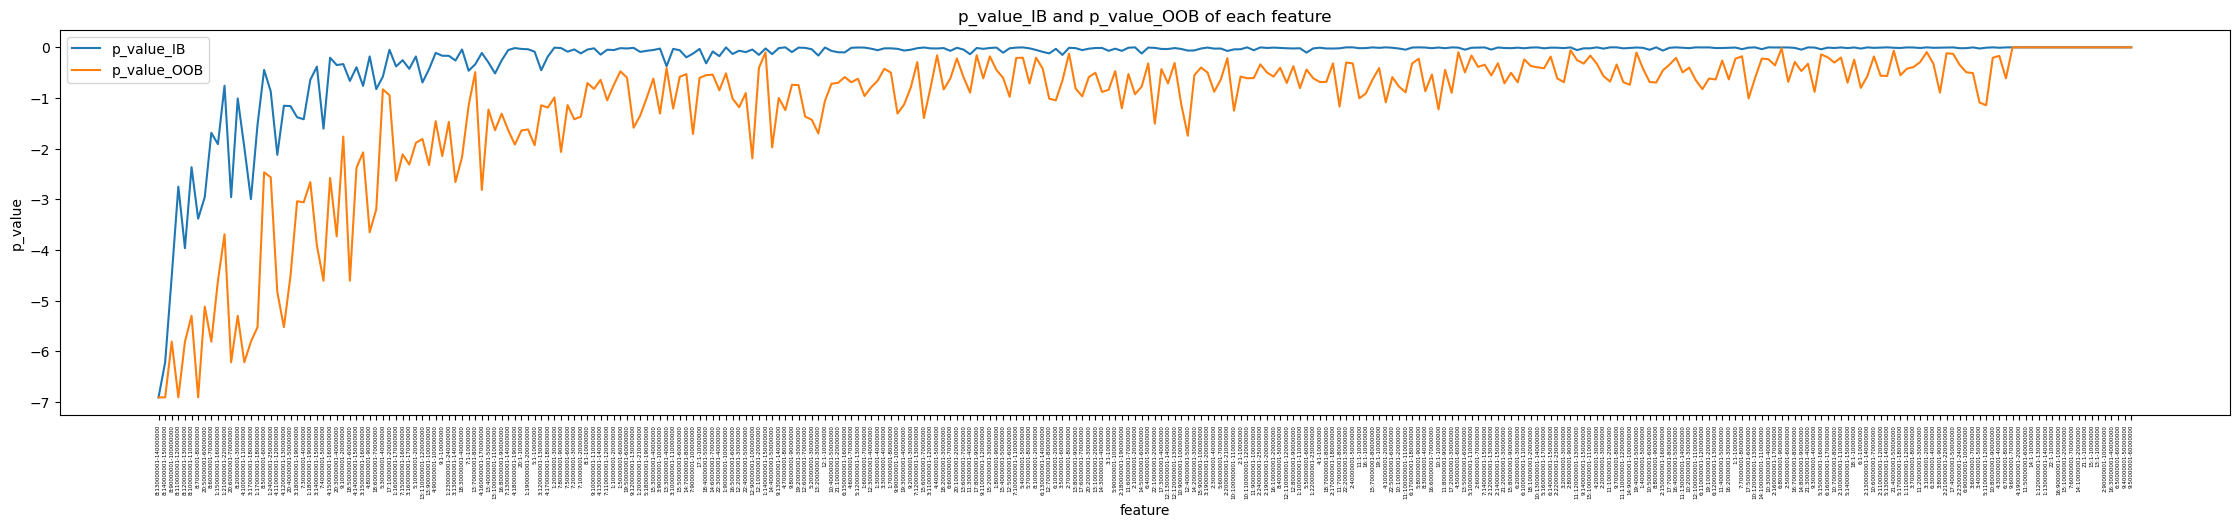

In [268]:
p_val_IB_OOB_sorted = p_val_IB_OOB.sort_values(by = 'mean_feature_importance_IB', ascending = False)
plt.figure(figsize=(28,5))
plt.plot(p_val_IB_OOB_sorted['feature'], np.log(p_val_IB_OOB_sorted['p_value_IB']), label = 'p_value_IB')
plt.plot(p_val_IB_OOB_sorted['feature'], np.log(p_val_IB_OOB_sorted['p_value_OOB']), label = 'p_value_OOB')
plt.xlabel('feature')
# make the xlabel smaller
plt.xticks(fontsize = 4)
plt.ylabel('p_value')
plt.title('p_value_IB and p_value_OOB of each feature')
# rotate the x-axis labels by 90 degrees
plt.xticks(rotation=90)
plt.legend()
plt.show()

In [32]:
from sklearn.inspection import permutation_importance
result = permutation_importance(model, X_test, y_test, n_repeats=10, n_jobs=-5)
sorted_importances_idx = result.importances_mean.argsort()
# sort the columns by sorted_idx
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_train.columns[sorted_importances_idx]
)
display(importances.head(20))

,4:180000001-190000000,4:120000001-130000000,8:1-10000000,4:80000001-90000000,4:130000001-140000000,5:180000001-190000000,4:100000001-110000000,8:20000001-30000000,4:110000001-120000000,17:1-10000000,...,5:130000001-140000000,5:120000001-130000000,5:110000001-120000000,5:100000001-110000000,5:90000001-100000000,5:150000001-160000000,8:70000001-80000000,8:140000001-150000000,8:90000001-100000000,8:130000001-140000000
0,-0.007092,-0.007092,-0.007092,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.007092,0.007092,0.000000
1,0.000000,-0.007092,0.000000,0.000000,0.000000,0.000000,-0.007092,0.000000,-0.007092,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.007092,0.007092,0.007092,0.007092
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.007092,0.007092,0.007092,0.014184
3,-0.007092,0.000000,-0.007092,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.007092,0.007092,0.007092,0.014184
4,-0.007092,0.000000,0.000000,-0.007092,-0.007092,-0.007092,0.000000,0.000000,-0.007092,-0.007092,...,0.0,0.0,0.0,0.0,0.0,0.0,0.007092,0.007092,0.007092,0.014184
5,-0.007092,0.000000,-0.007092,0.000000,0.000000,-0.007092,0.000000,-0.007092,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.007092,0.000000,0.007092,0.014184
6,-0.007092,0.000000,-0.007092,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.007092,0.007092,0.007092
7,-0.007092,-0.007092,0.000000,0.000000,0.000000,0.000000,-0.007092,-0.007092,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.007092,0.007092
9,-0.007092,-0.007092,0.000000,-0.007092,-0.007092,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.007092,0.007092,0.007092,0.014184


In [41]:
# get the mean feature importance from the random forest model
feature_importance_origin = [tree.feature_importances_ for tree in model.estimators_]
feature_importance = np.mean(feature_importance_origin, axis=0)

print(feature_importance.shape)
# get the column names
columns = wise_X.columns
print(columns.shape)
# create a dataframe
df = pd.DataFrame({'feature': columns, 'importance': feature_importance})
# sort the dataframe
df.sort_values('importance', ascending = False).to_csv("mean_feature_importance.csv",index=False)
df.sort_values('importance', ascending = False)[:20]


(300,)
(300,)


,feature,importance
156,8:130000001-140000000,0.067590
157,8:140000001-150000000,0.055604
154,8:110000001-120000000,0.042967
155,8:120000001-130000000,0.040197
150,8:70000001-80000000,0.039449
152,8:90000001-100000000,0.036767
153,8:100000001-110000000,0.022659
17,1:170000001-180000000,0.021825
21,1:210000001-220000000,0.021697
145,8:20000001-30000000,0.020939


In [17]:
# pd.DataFrame(wise_X.columns[np.argsort(ss.rankdata(ps_adusted, method='min'))[:]]).to_csv('wise_rank.csv', index=False)
# pd.DataFrame(wise_X.columns[np.argsort(ss.rankdata(p_val, method='min'))[:]]).to_csv('wise_rank_pval.csv', index=False)

In [46]:

X = wise_all_X
y = wise_all_y
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
# train using 
model = RandomForestClassifier(n_estimators=1000, n_jobs=10)
permuted_model = RandomForestClassifier(n_estimators=1000, n_jobs=10)
model.fit(X_train,y_train)
# test the model on the test data
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

# feature_importance_origin = model.feature_importances_
# del model
feature_importance_origin = [tree.feature_importances_ for tree in model.estimators_]
# print(len(feature_importance_origin[0]))
y_cp = y_train.copy()
# shuffle the labels
y_cp = np.random.permutation(y_cp)
# np.random.shuffle(y_cp)
permuted_model.fit(X_train,y_cp)
permuted_feature_importance = [tree.feature_importances_ for tree in permuted_model.estimators_]
# del permuted_model
feature_importance = np.concatenate((feature_importance_origin,permuted_feature_importance))
# print(len(feature_importance))
stat, p_val, ps_adusted = test(feature_importance,
            n_repeats = 1000,
            n_jobs = 10,
            n_estimators = 1000)

0.8095238095238095


In [48]:
# sort the columns by p-value
p_val_df_all = pd.DataFrame(p_val, columns = ['p_value'])
p_val_df_all['feature'] = X_train.columns
p_val_sorted_all = p_val_df.sort_values(by = 'p_value')
k = len(p_val_sorted_all)
rev_idx = np.linspace(1, k, k)[::-1]
# multiply the p-values by the number of tests
p_val_sorted_all['p_value_adjusted'] = p_val_sorted_all['p_value'] * rev_idx/k
# sort the p-values by the adjusted p-values
p_val_sorted_all.sort_values(by = 'p_value_adjusted')[:].drop(columns = ['p_value']).to_csv('wise_feature_importance_all.csv', index = False)
p_val_sorted_all.sort_values(by = 'p_value_adjusted')[:].drop(columns = ['p_value'])[:20]

,feature,p_value_adjusted
157,8:140000001-150000000,0.000996
156,8:130000001-140000000,0.000999
258,16:90000001-100000000,0.003333
155,8:120000001-130000000,0.005954
13,1:130000001-140000000,0.006667
154,8:110000001-120000000,0.007912
189,11:20000001-30000000,0.010000
236,14:90000001-100000000,0.013333
288,20:60000001-70000000,0.015771
181,10:80000001-90000000,0.016667


In [ ]:
import pa